# Slopes of Inverse Functions with a simple function

$
f(x) = x^3 + x.
$

This function is strictly increasing (because $ f'(x) = 3x^2 + 1 > 0 $), so it has an inverse.

We will compute:

- The inverse function numerically
- The slope of the inverse at a point
- The reciprocal‑slope rule:
  

$
  (f^{-1})'(y) = \frac{1}{f'(x)} \quad \text{where } y = f(x)
$

We will also visualize the tangent lines to $ f $ and $ f^{-1} $ at corresponding points.


In [43]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()

x, y = sp.symbols('x y', real=True)

f = x**3 + x
f_prime = sp.diff(f, x)

f, f_prime


## Example point

Let:



$
x_0 = 1,\quad y_0 = f(1) = 1^3 + 1 = 2.
$



We want the slope of the inverse at $ y_0 = 2 $.


In [44]:
x0 = 1
y0 = f.subs(x, x0)
x0, y0


## Slope of the inverse

The rule says:



$
(f^{-1})'(y_0) = \frac{1}{f'(x_0)}.
$



Since:



$
f'(x) = 3x^2 + 1,
$



we have:



$
f'(1) = 4.
$



Thus:



$
(f^{-1})'(2) = \frac{1}{4}.
$




In [45]:
slope_inverse = 1 / f_prime.subs(x, x0)
slope_inverse


In [46]:
# Solve f(x) = y0 for x
inverse_solution = sp.nsolve(f - y0, 0.5)  # initial guess near 1
inverse_solution


The numerical inverse gives $ f^{-1}(2) = 1 $, as expected.

We can approximate the derivative of the inverse numerically using a symmetric difference quotient.


In [47]:
h = 1e-5
num_slope = (sp.nsolve(f - (y0 + h), 1) - sp.nsolve(f - (y0 - h), 1)) / (2*h)
float(num_slope)


## Visualizing reciprocal slopes

We will plot:

- $ f(x) = x^3 + x $
- Its inverse (computed numerically)
- Tangent line to $ f $ at $ x_0 = 1 $
- Tangent line to $ f^{-1} $ at $ y_0 = 2 $

The slopes should be reciprocals: $ 4 $ and $ 1/4 $.


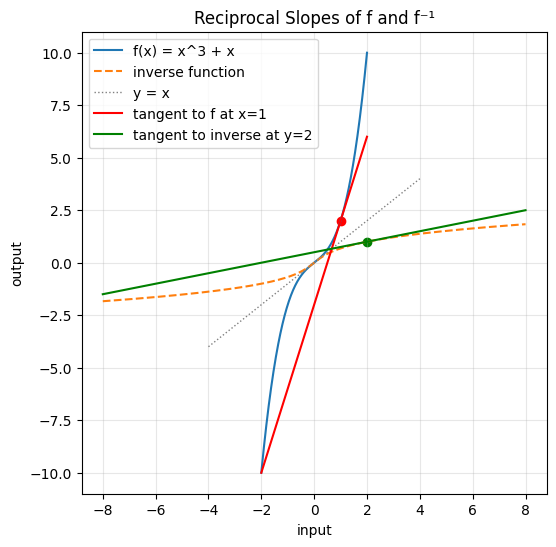

In [ ]:
# Generate data for f
xs = np.linspace(-2, 2, 400)
ys = xs**3 + xs

# Generate data for inverse by solving f(x)=y for each y
ys_inv = np.linspace(-8, 8 , 400)
xs_inv = [float(sp.nsolve(f - yi, 0)) for yi in ys_inv]

# Tangent line to f at x0
m_f = float(f_prime.subs(x, x0))
b_f = float(y0 - m_f*x0)
tangent_f = m_f*xs + b_f

# Tangent line to inverse at y0
m_inv = float(slope_inverse)
b_inv = float(x0 - m_inv*y0)
tangent_inv = m_inv*ys_inv + b_inv

plt.figure(figsize=(6, 6))
plt.plot(xs, ys, label='f(x) = x^3 + x')
plt.plot(ys_inv, xs_inv, label='inverse function', linestyle='--')

# Symmetry line y = x
lim = 4
plt.plot([-lim, lim], [-lim, lim], label='y = x', color='gray', linestyle=':', linewidth=1)

plt.plot(xs, tangent_f, label='tangent to f at x=1', color='red')
plt.plot(ys_inv, tangent_inv, label='tangent to inverse at y=2', color='green')

plt.scatter([x0], [y0], color='red')
plt.scatter([y0], [x0], color='green')

plt.grid(alpha=0.3)
plt.legend()
plt.title("Reciprocal Slopes of f and f⁻¹")
plt.xlabel("input")
plt.ylabel("output")
plt.show()


# Summary

For $ f(x) = x^3 + x $:

- $ f'(x) = 3x^2 + 1 > 0 $, so $ f $ is invertible.
- At $ x_0 = 1 $, $ y_0 = f(1) = 2 $.
- Slope of $ f $ at $ x_0 $:  
  

$
  f'(1) = 4.
  $


- Slope of the inverse at $ y_0 $:  
  

$
  (f^{-1})'(2) = \frac{1}{4}.
  $



This demonstrates the inverse‑slope rule:



$
(f^{-1})'(y) = \frac{1}{f'(x)} \quad \text{where } y = f(x).
$


